In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
folder_dir = 'drive/MyDrive/train/'
labels = os.listdir(folder_dir)
labels

['yawn', 'no_yawn', 'Open', 'Closed']

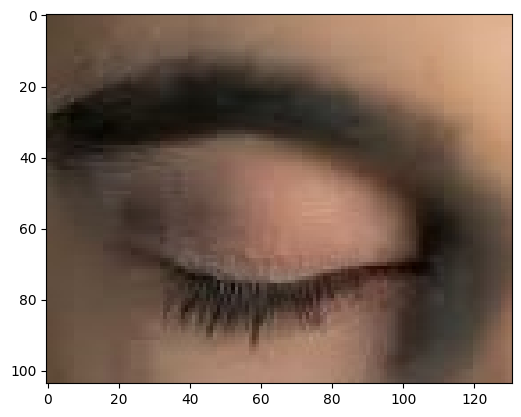

In [ ]:
plt.imshow(plt.imread(folder_dir+"Closed/_26.jpg"))

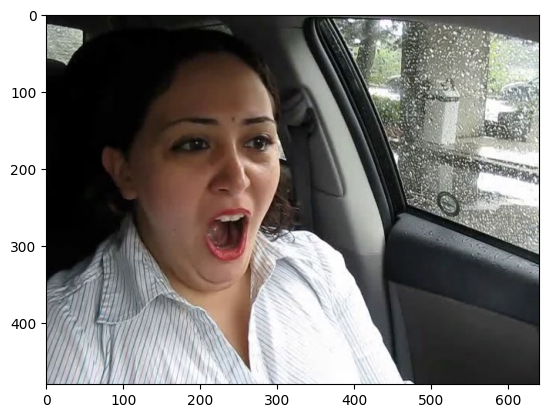

In [ ]:
plt.imshow(plt.imread(folder_dir+"yawn/109.jpg"))  # display the first image in the yawn_no_yawn list

## Preprocessing Images
### Yawning Dataset: Resizing + Crop Faces + Yawning Label

In [ ]:
def face_for_yawn(direc=folder_dir, face_cas_path=cv2.data.haarcascades + "haarcascade_frontalface_default.xml"):
    yaw_no = []  # create an empty list to store .image arrays and their respective class numbers
    IMG_SIZE = 145  # define the size of the image to be resized to
    categories = ["yawn", "no_yawn"]  # define the categories of the images
    for category in categories:
        path_link = os.path.join(direc, category)  # create a path to the directory of each category
        class_num1 = categories.index(category)  # assign a unique class number to each category
        print(class_num1)  # print the class number for debugging purposes
        for image in os.listdir(path_link):  # loop through all the images in the directory
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)  # read the image and store it as an array
            face_cascade = cv2.CascadeClassifier(face_cas_path)  # load the face cascade classifier
            faces = face_cascade.detectMultiScale(image_array, 1.3, 5)  # detect all faces in the image
            for (x, y, w, h) in faces:  # loop through all the detected faces
                img = cv2.rectangle(image_array, (x, y), (x+w, y+h), (0, 255, 0), 2)  # draw a rectangle around the face
                roi_color = img[y:y+h, x:x+w]  # crop the image to only include the face
                resized_array = cv2.resize(roi_color, (IMG_SIZE, IMG_SIZE))  # resize the cropped image to the desired size
                yaw_no.append([resized_array, class_num1])  # add the resized image and its class number to the list
    return yaw_no  # return the list of resized images and their class numbers


yawn_no_yawn = face_for_yawn()  # call the face_for_yawn function and store the result in yawn_no_yawn variable

0
1


### Eyes Dataset: Resizing Images + Eyes Label

In [ ]:
# This function is getting data from a directory
# It is resizing the images to a specified size and appending the resized image and its label to a list
# The function returns the list of data
def get_data(dir_path=folder_dir):
    # Define the labels for the data
    labels = ['Closed', 'Open']
    # Define the size of the images after resizing
    IMG_SIZE = 145
    # Create an empty list to store the data
    data = []
    # Loop through each label in the labels list
    for label in labels:
        # Define the path to the label's directory
        path = os.path.join(dir_path, label)
        # Get the index of the label in the labels list
        class_num = labels.index(label)
        # Add 2 to the class number to account for the additional classes for face and eyes
        class_num += 2
        # Loop through each image in the label's directory
        for img in os.listdir(path):
            try:
                # Read in the image and resize it
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                # Append the resized image and its label to the data list
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    # Return the list of data
    return data
data_train = get_data()

In [ ]:
data_train[0][0].shape

(145, 145, 3)

### Preprocessed Data Combination

In [ ]:
def append_data():
    # call the `face_for_yawn()` function to get yawning and non-yawning face images
    yaw_no = face_for_yawn()

    # call the `get_data()` function to get open and closed eye images
    data = get_data()

    # combine the two datasets into a single list using the `extend()` method
    yaw_no.extend(data)

    # return the resulting list as a standard Python list
    return yaw_no

new_data = append_data()

0
1


### Transforming Appended Dataset and Splitting Features

In [ ]:
# Initialize empty lists to store features and labels
X = []
y = []

# Iterate over each tuple of feature and label in the new_data list
for feature, label in new_data:

    # Append the feature to the X list
    X.append(feature)

    # Append the label to the y list
    y.append(label)
# Features
X = np.array(X)
X = X.reshape(-1, 145, 145, 3)

### One-hot Encoding the Labels (possible classes 0,1,2,3) using Label Binarizer

In [ ]:
from sklearn.preprocessing import LabelBinarizer
label_bin = LabelBinarizer()
y = label_bin.fit_transform(y)

In [ ]:
# Labels
y = np.array(y)

### Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.20
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=test_size)

### Importing Modules

In [ ]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

### Data Augmentation

In [ ]:
train_generator = ImageDataGenerator(rescale=1/255, zoom_range=0.2, horizontal_flip=True, rotation_range=30)
test_generator = ImageDataGenerator(rescale=1/255)

train_generator = train_generator.flow(np.array(X_train), y_train, shuffle=False)
test_generator = test_generator.flow(np.array(X_test), y_test, shuffle=False)

### Model Compiling

In [ ]:
# Create a Sequential model
model = Sequential()

# Add convolutional layers with ReLU activation and MaxPooling layers
model.add(Conv2D(512, (3, 3), activation="relu", input_shape=X_train.shape[1:]))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(512, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(256, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(256, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(256, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

# Flatten the output and add a Dropout layer
model.add(Flatten())
model.add(Dropout(0.5))

# Add Dense layers with ReLU activation and a Softmax output layer
model.add(Dense(128, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(4, activation="softmax"))

# Compile the model with categorical cross-entropy loss, accuracy metric, and Adam optimizer
model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

# Print the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 143, 143, 512)  │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 71, 71, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 69, 69, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,873,924 (18.59 MB)

 Trainable params: 4,873,924 (18.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=20,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

history = model.fit(train_generator, epochs=50, validation_data=test_generator, shuffle=True, validation_steps=len(test_generator), callbacks=[early_stopping])

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 85s 931ms/step - accuracy: 0.4455 - loss: 1.2276 - val_accuracy: 0.6260 - val_loss: 0.9455
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.7286 - loss: 0.6785 - val_accuracy: 0.7844 - val_loss: 0.5136
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 433ms/step - accuracy: 0.8136 - loss: 0.4025 - val_accuracy: 0.8130 - val_loss: 0.3370
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 439ms/step - accuracy: 0.8364 - loss: 0.3555 - val_accuracy: 0.8909 - val_loss: 0.2828
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 440ms/step - accuracy: 0.8675 - loss: 0.3032 - val_accuracy: 0.8623 - val_loss: 0.2658
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 445ms/step - accuracy: 0.8935 - loss: 0.2449 - val_accuracy: 0.9117 - val_loss: 0.1872
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 461ms/step - accuracy: 0.8987 - loss: 0.2467 - val_accuracy: 0.9221 - val_loss: 0.1975
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 452ms/step - accuracy: 0.9078 - loss: 0.2160 - val_accu

## Saving the Model

In [ ]:
model.save("drowiness_from_scratch.keras")

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.9610 - loss: 0.0815


In [ ]:
def get_label(prediction_label):
    if prediction_label == 0:
        print("STAY ALERT! YOU'RE DOZING OFF!")
        print("Yawning Detected")
    elif prediction_label == 1:
        print("No Yawning Detected")
    elif prediction_label == 2:
        print("STAY ALERT! YOU'RE DOZING OFF!")
        print("Eyes are closed")
    elif prediction_label == 3:
        print("Eyes are open")
    else:
        raise ValueError("Invalid index")

In [1]:
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt

# Class index contract from training pipeline.
CLASS_NAMES = {
    0: "yawn",
    1: "no_yawn",
    2: "eyes_closed",
    3: "eyes_open",
}

EYE_CLASS_IDS = [2, 3]
MOUTH_CLASS_IDS = [0, 1]
CONFIDENCE_THRESHOLD = 0.55

# Match Colab training/export setup exactly.
MODEL_PATH = "drowiness_from_scratch.keras"
MODEL_IMG_SIZE = 145

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

# compile=False avoids cross-version compile/optimizer issues for inference-only use.
model_for_inference = load_model(MODEL_PATH, compile=False)

face_cascade_infer = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade_infer = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

def preprocess_roi_for_model(roi_bgr, img_size=MODEL_IMG_SIZE):
    if roi_bgr is None or roi_bgr.size == 0:
        return None

    # Colab training used cv2.imread + ImageDataGenerator(rescale=1/255), i.e. BGR + [0, 1] scaling.
    resized = cv2.resize(roi_bgr, (img_size, img_size)).astype(np.float32)
    x = resized / 255.0
    return np.expand_dims(x, axis=0)

def predict_subset(roi_bgr, allowed_ids):
    x = preprocess_roi_for_model(roi_bgr)
    if x is None:
        return "not_detected", 0.0
    probs = model_for_inference.predict(x, verbose=0)[0]
    subset = np.array([probs[i] for i in allowed_ids], dtype=np.float32)
    subset = subset / (subset.sum() + 1e-8)
    best_local_idx = int(np.argmax(subset))
    class_id = allowed_ids[best_local_idx]
    confidence = float(subset[best_local_idx])
    if confidence < CONFIDENCE_THRESHOLD:
        return "uncertain", confidence
    return CLASS_NAMES[class_id], confidence

def predict_mouth_state(face_bgr, mouth_roi_bgr):
    # Important: training yawn/no_yawn samples were face crops, not isolated mouth crops.
    face_label, face_conf = predict_subset(face_bgr, MOUTH_CLASS_IDS)
    mouth_label, mouth_conf = predict_subset(mouth_roi_bgr, MOUTH_CLASS_IDS)

    # Prefer face-based prediction for consistency with training distribution.
    # Use mouth ROI only when face prediction is uncertain.
    if face_label == "uncertain" and mouth_label not in ["not_detected", "uncertain"]:
        return mouth_label, mouth_conf
    return face_label, face_conf

def draw_box_with_label(image_bgr, box, label, confidence, color):
    x, y, w, h = box
    cv2.rectangle(image_bgr, (x, y), (x + w, y + h), color, 2)
    text = f"{label} ({confidence:.2f})"
    cv2.putText(image_bgr, text, (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA)

def mouth_box_from_face(face_box):
    x, y, w, h = face_box
    mx = x + int(0.18 * w)
    my = y + int(0.58 * h)
    mw = int(0.64 * w)
    mh = int(0.34 * h)
    return (mx, my, mw, mh)

def detect_and_annotate_states(image_bgr):
    output = image_bgr.copy()
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade_infer.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(80, 80))

    if len(faces) == 0:
        # Fallback: run mouth-state prediction on the full frame.
        label, conf = predict_subset(image_bgr, MOUTH_CLASS_IDS)
        h, w = image_bgr.shape[:2]
        draw_box_with_label(output, (10, 10, w - 20, h - 20), f"fallback_mouth:{label}", conf, (0, 165, 255))
        return output

    for (x, y, w, h) in faces:
        face_box = (x, y, w, h)
        cv2.rectangle(output, (x, y), (x + w, y + h), (255, 255, 0), 2)
        cv2.putText(output, "face", (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2, cv2.LINE_AA)

        face_gray = gray[y:y+h, x:x+w]
        face_bgr = image_bgr[y:y+h, x:x+w]

        eyes = eye_cascade_infer.detectMultiScale(face_gray, scaleFactor=1.15, minNeighbors=6, minSize=(20, 20))
        eyes = sorted(eyes, key=lambda e: e[0])[:2]

        for (ex, ey, ew, eh) in eyes:
            eye_roi = face_bgr[ey:ey+eh, ex:ex+ew]
            eye_label, eye_conf = predict_subset(eye_roi, EYE_CLASS_IDS)
            global_eye_box = (x + ex, y + ey, ew, eh)
            draw_box_with_label(output, global_eye_box, f"eye:{eye_label}", eye_conf, (0, 255, 0))

        mbox = mouth_box_from_face(face_box)
        mx, my, mw, mh = mbox
        mouth_roi = image_bgr[my:my+mh, mx:mx+mw]
        mouth_label, mouth_conf = predict_mouth_state(face_bgr, mouth_roi)
        draw_box_with_label(output, mbox, f"mouth:{mouth_label}", mouth_conf, (0, 0, 255))

    return output

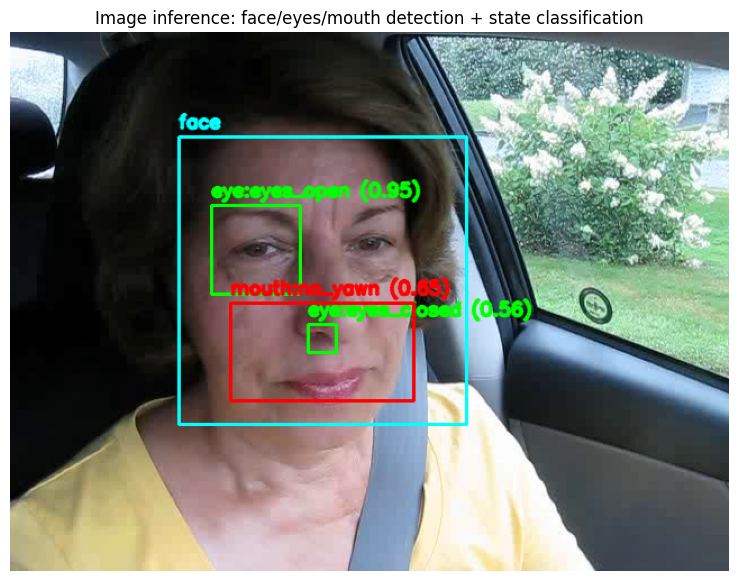

In [ ]:
# IMAGE DEMO: set any local image path here and run this cell.
image_path = folder_dir+"no_yawn/2464.jpg"

image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

annotated = detect_and_annotate_states(image_bgr)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Image inference: face/eyes/mouth detection + state classification")
plt.show()

In [2]:
# WEBCAM DEMO: run this cell after image demo works.
# Press 'q' in the webcam window to quit.

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Could not open webcam. Make sure camera permissions are enabled.")

print("Webcam started. Press 'q' to quit.")
while True:
    ok, frame = cap.read()
    if not ok:
        break

    annotated = detect_and_annotate_states(frame)
    cv2.imshow("Drowsiness Demo - face/eyes/mouth", annotated)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Webcam stopped.")

Webcam started. Press 'q' to quit.
Webcam stopped.
